In [1]:
import os
from getpass import getpass
from urllib.parse import quote

REPO_URL = "https://github.com/williamsnunezp/prediccion-atenciones-medicas-salud.git"
REPO_DIR = "/content/prediccion-atenciones-medicas-salud"

token = os.getenv("GITHUB_TOKEN")
if token is None:
    token = getpass("GitHub token (deja vacío si el repo es público o ya fue cargado): ").strip()

if token:
    token = quote(token, safe="")
    clone_url = REPO_URL.replace("https://", f"https://{token}@")
else:
    clone_url = REPO_URL

if not os.path.exists(REPO_DIR):
    !git clone {clone_url} {REPO_DIR}
else:
    print("Ya existe:", REPO_DIR)

print(f"Entorno listo: {os.listdir(REPO_DIR)}")


Cloning into '/content/prediccion-atenciones-medicas-salud'...
remote: Enumerating objects: 407, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 407 (delta 51), reused 98 (delta 22), pack-reused 270 (from 1)
Receiving objects: 100% (407/407), 88.06 MiB | 20.75 MiB/s, done.
Resolving deltas: 100% (162/162), done.
Entorno listo: ['notebooks', 'data', 'requirements.txt', 'README.md', '.gitignore', '.git', 'articles', '.vscode']


# **Fase 3: Preparación de los datos (CRISP-DM)**

En esta fase se seleccionan, limpian y transforman los datos para construir el dataset de entrenamiento. El objetivo es estructurar las variables predictoras y la variable objetivo para maximizar la capacidad de aprendizaje de los modelos XGBoost y LightGBM.

In [2]:
# Librerías base
import pandas as pd
import os
import zipfile
import numpy as np
import warnings

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y escalado
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder

#
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from scipy.stats import chi2_contingency
from sklearn.metrics import mutual_info_score
from sklearn.model_selection import train_test_split
import shap
import xgboost as xgb
import lightgbm as lgb


# Opcional
warnings.filterwarnings("ignore")

In [3]:
# Ruta al archivo ZIP
ruta_zip = os.path.join("/content/prediccion-atenciones-medicas-salud", "data", "dataraw.zip")

# Abrir el ZIP y listar archivos
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    # Listar archivos en el ZIP
    archivos = zip_ref.namelist()
    print("Archivos en el ZIP:")
    print(archivos)
    
    # Leer el CSV directamente desde el ZIP con separador ";"
    archivo_csv = [f for f in archivos if f.endswith('.csv')][0]
    
    with zip_ref.open(archivo_csv) as csv_file:
        data = pd.read_csv(csv_file, sep=";")

data.tail(3)

Archivos en el ZIP:
['DATOS HOSPITAL MARIA AUXILIADORA.csv']


,FECHA_CORTE,ID,DIA_SOLICITACITA,DIA_CITA,ESPECIALIDAD,SEXO,EDAD,SEGURO,PRESENCIAL_REMOTO,ATENDIDO,MONTO,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO
450626,20240430,1373246,20231205,20231230,PSICOLOGIA,FEMENINO,8.0,SI,PRESENCIAL,NO,30,LIMA,LIMA,SAN JUAN DE MIRAFLORES,150133
450627,20240430,2118536,20231205,20231230,PSICOLOGIA,MASCULINO,6.0,SI,PRESENCIAL,NO,30,LIMA,LIMA,SAN JUAN DE MIRAFLORES,150133
450628,20240430,2346541,20231207,20231230,PSICOLOGIA,MASCULINO,11.0,NO,PRESENCIAL,NO,30,LIMA,LIMA,SAN JUAN DE MIRAFLORES,150133


## 3.1. Selección de datos iniciales

Se seleccionan las 10 variables principales identificadas en la **Fase 2 (Comprensión de los datos)** que muestran relación directa con la asistencia, excluyendo variables de ubicación geográfica (como UBIGEO, provincia o distrito) por no aportar valor predictivo generalizable.

In [4]:
#3.1. Seleccion de variables
print("Columnas del dataset:", data.columns.tolist())
data1 = data.iloc[:, 1:11]
data1.head(3)

Columnas del dataset: ['FECHA_CORTE', 'ID', 'DIA_SOLICITACITA', 'DIA_CITA', 'ESPECIALIDAD', 'SEXO', 'EDAD', 'SEGURO', 'PRESENCIAL_REMOTO', 'ATENDIDO', 'MONTO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'UBIGEO']


,ID,DIA_SOLICITACITA,DIA_CITA,ESPECIALIDAD,SEXO,EDAD,SEGURO,PRESENCIAL_REMOTO,ATENDIDO,MONTO
0,155034,20221220,20230102,GERIATRIA,FEMENINO,77.0,SI,REMOTO,SI,33
1,612796,20221223,20230102,GASTROENTEROLOGIA,FEMENINO,37.0,SI,PRESENCIAL,SI,7
2,1576812,20221212,20230102,ENDOCRINOLOGIA,MASCULINO,70.0,NO,PRESENCIAL,SI,7


## 3.2. Formateo y codificación de tipos de datos

Se ajustan los formatos del dataset para prepararlo para el modelado:
* **Fechas**: Conversión de fechas de solicitud y cita a tipo `datetime64`.
* **Target (`atendido`)**: Codificación binaria (asistencia `SI` = 0; inasistencia `NO` = 1) para establecer la inasistencia como la clase positiva (1).
* **Categóricas**: Conversión de variables de texto a tipo `category`.

In [5]:
#3.3. Corregir tipos de datos categoricos
def corregir_tipos_de_datos(data1):

  col1 = ['dia_solicitacita', 'dia_cita','especialidad', 'seguro', 'sexo', 'presencial_remoto','monto', 'atendido']

  data1.columns = data1.columns.str.lower()
  data1col = data1.columns.tolist()
    
  if col1[0] in data1col and col1[1] in data1col:
    data1[[col1[0], col1[1]]] = data1[[col1[0], col1[1]]].apply(pd.to_datetime, format='%Y%m%d')
  # Convetir 'SI' y 'NO' a 1 y 0
  if col1[7] in data1col:
    data1[col1[7]]= data1[col1[7]].map({'SI':0, 'NO':1}).astype('int')
  # Convertir columnas de string a tipo category
  for col in data1[col1]:
    if col in [col1[0], col1[1], col1[7]]:
      continue
    data1[col]= data1[col].astype('category')

  return data1

data1 = corregir_tipos_de_datos(data1)

## 3.3. Construcción de variables (Feature Engineering)

Se diseñan nuevas variables predictoras de alto valor operativo:
* **Temporales**: `diferencia_dias` (tiempo de espera), `mes_cita`, `dia_mes_cita`, `semana_mes_cita`, `cita_mes_diferente` y `estacion_cita`.
* **Rango de Edad**: Segmentación de edad por ciclo de vida (`rango_edad`) y cruces categóricos (`edad_sexo`, `edad_monto`, `sexo_monto`).
* **Historial del Paciente**: Comportamiento previo usando variables acumulativas (`citas_previas`, `noshow_previos` y `tasa_noshow_previa`).

In [6]:
def crear_variables(data1):
    """
    Crea variables derivadas para el modelado predictivo.
    Requiere columnas en orden: id, dia_solicitacita, dia_cita, especialidad,
    sexo, edad, seguro, presencial_remoto, atendido, monto.
    """
    data1col = data1.columns.tolist()

    # ── Variables derivadas de fecha ──────────────────────────────────────────
    def obtener_estacion(fecha):
        año = fecha.year
        if pd.Timestamp(f'{año}-12-21') <= fecha or fecha < pd.Timestamp(f'{año}-3-21'):
            return 'verano'
        elif pd.Timestamp(f'{año}-3-21') <= fecha < pd.Timestamp(f'{año}-6-21'):
            return 'otoño'
        elif pd.Timestamp(f'{año}-6-21') <= fecha < pd.Timestamp(f'{año}-9-23'):
            return 'invierno'
        else:
            return 'primavera'

    data1['diferencia_dias'] = (data1[data1col[2]] - data1[data1col[1]]).dt.days.astype('float32')
    data1['mes_cita'] = data1[data1col[2]].dt.month.astype('category')
    data1['dia_mes_cita'] = data1[data1col[2]].dt.day.astype('category')
    data1['semana_mes_cita'] = (((data1[data1col[2]].dt.day - 1) // 7) + 1).clip(upper=4).astype('category')
    data1['cita_mes_diferente'] = (data1[data1col[1]].dt.month != data1[data1col[2]].dt.month).astype(int).astype('category')
    data1['estacion_cita'] = data1[data1col[2]].apply(obtener_estacion).astype('category')

    # ── Categorización de edad ────────────────────────────────────────────────
    bins = [0, 12, 18, 30, 60, np.inf]
    labels = [
        'Pediatria',      # 0-11
        'Adolescente',    # 12-17
        'Adulto_joven',   # 18-29
        'Adulto',         # 30-59
        'Adulto_mayor'    # 60+
    ]
    data1['edad'] = data1[data1col[5]].abs()
    data1['rango_edad'] = pd.cut(data1[data1col[5]], bins=bins, labels=labels, right=False).astype('category')

    # ── Variables combinadas ──────────────────────────────────────────────────
    data1['edad_sexo'] = (data1['rango_edad'].astype(str) + '_' + data1[data1col[4]].astype(str)).astype('category')
    data1['edad_monto'] = (data1['rango_edad'].astype(str) + '_' + data1[data1col[9]].astype(str)).astype('category')
    data1['sexo_monto'] = (data1[data1col[4]].astype(str) + '_' + data1[data1col[9]].astype(str)).astype('category')

    # ── Variables acumulativas por paciente ────────────────────────────────────
    data1 = data1.sort_values([data1col[0], data1col[2]])
    data1['citas_previas'] = (data1
        .groupby(data1col[0])[data1col[8]]
        .transform(lambda x: x.shift(1).count())
        .fillna(0).astype('float32'))
    data1['noshow_previos'] = (data1
        .groupby(data1col[0])[data1col[8]]
        .transform(lambda x: x.shift(1).expanding().sum())
        .fillna(0).astype('float32'))
    data1['tasa_noshow_previa'] = (data1['noshow_previos'] / data1['citas_previas']).fillna(-1).astype('category')
    data1[['citas_previas', 'noshow_previos']] = data1[['citas_previas', 'noshow_previos']].astype('category')

    return data1

data1 = crear_variables(data1)


## 3.4. Limpieza de datos y filtrado de inconsistencias

Se realiza la depuración final del dataset antes de entrenar y analizar mediante SHAP:
* **Filtro de especialidades**: Se conservan especialidades con al menos 365 citas anuales para garantizar representatividad y se quitan aquellas con baja variación.
* **Valores nulos**: Eliminación de registros con valores faltantes en `edad` y `seguro`.
* **Consistencia temporal**: Corrección de valores de `edad` a su valor absoluto y eliminación de registros donde `diferencia_dias` sea menor que 0.

In [7]:
#3.3. Eliminamos datos inconsistentes
def limpiar_datos(data1):

  col2 = ['especialidad', 'edad','seguro', 'diferencia_dias', 'atendido']
  data1col = data1.columns.tolist()

  # columna especialidad y atendido
  if col2[0] in data1col:
    probs = (
        data1.groupby(col2[0])[col2[4]].value_counts(normalize=True).unstack(fill_value=0))
    drop_levels = probs[(probs[0] >= 0.9) | (probs[1] >= 0.9)].index
    
    data1 = data1[~data1[col2[0]].isin(drop_levels)].copy()
    data1[col2[0]] = data1[col2[0]].cat.remove_unused_categories()
    data1 = data1[data1.groupby(col2[0])[col2[0]].transform('count') >= 365]
  
  # Columna edad y seguro
  if col2[1] in data1col and col2[2] in data1col:
    # Eliminar nulos
    data1 = data1.dropna(subset=[col2[1],col2[2]])
    # convertir a positivos, Edad a valor absoluto
    data1[col2[1]]= data1[col2[1]].abs().astype({col2[1]:'float32'})
  
  # Columna diferencia_dias
  if col2[3] in data1col:
    negativos = (data1[col2[3]] < 0).sum()
    if negativos > 0:
      data1 = data1[data1[col2[3]] >= 0]

  # Reiniciar indice
  return data1.reset_index(drop=True)

data1 = limpiar_datos(data1)

In [8]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412579 entries, 0 to 412578
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  412579 non-null  int64         
 1   dia_solicitacita    412579 non-null  datetime64[ns]
 2   dia_cita            412579 non-null  datetime64[ns]
 3   especialidad        412579 non-null  category      
 4   sexo                412579 non-null  category      
 5   edad                412579 non-null  float32       
 6   seguro              412579 non-null  category      
 7   presencial_remoto   412579 non-null  category      
 8   atendido            412579 non-null  int64         
 9   monto               412579 non-null  category      
 10  diferencia_dias     412579 non-null  float32       
 11  mes_cita            412579 non-null  category      
 12  dia_mes_cita        412579 non-null  category      
 13  semana_mes_cita     412579 no

Clase 0: 245,237 | Clase 1: 84,826 | scale_pos_weight: 2.891


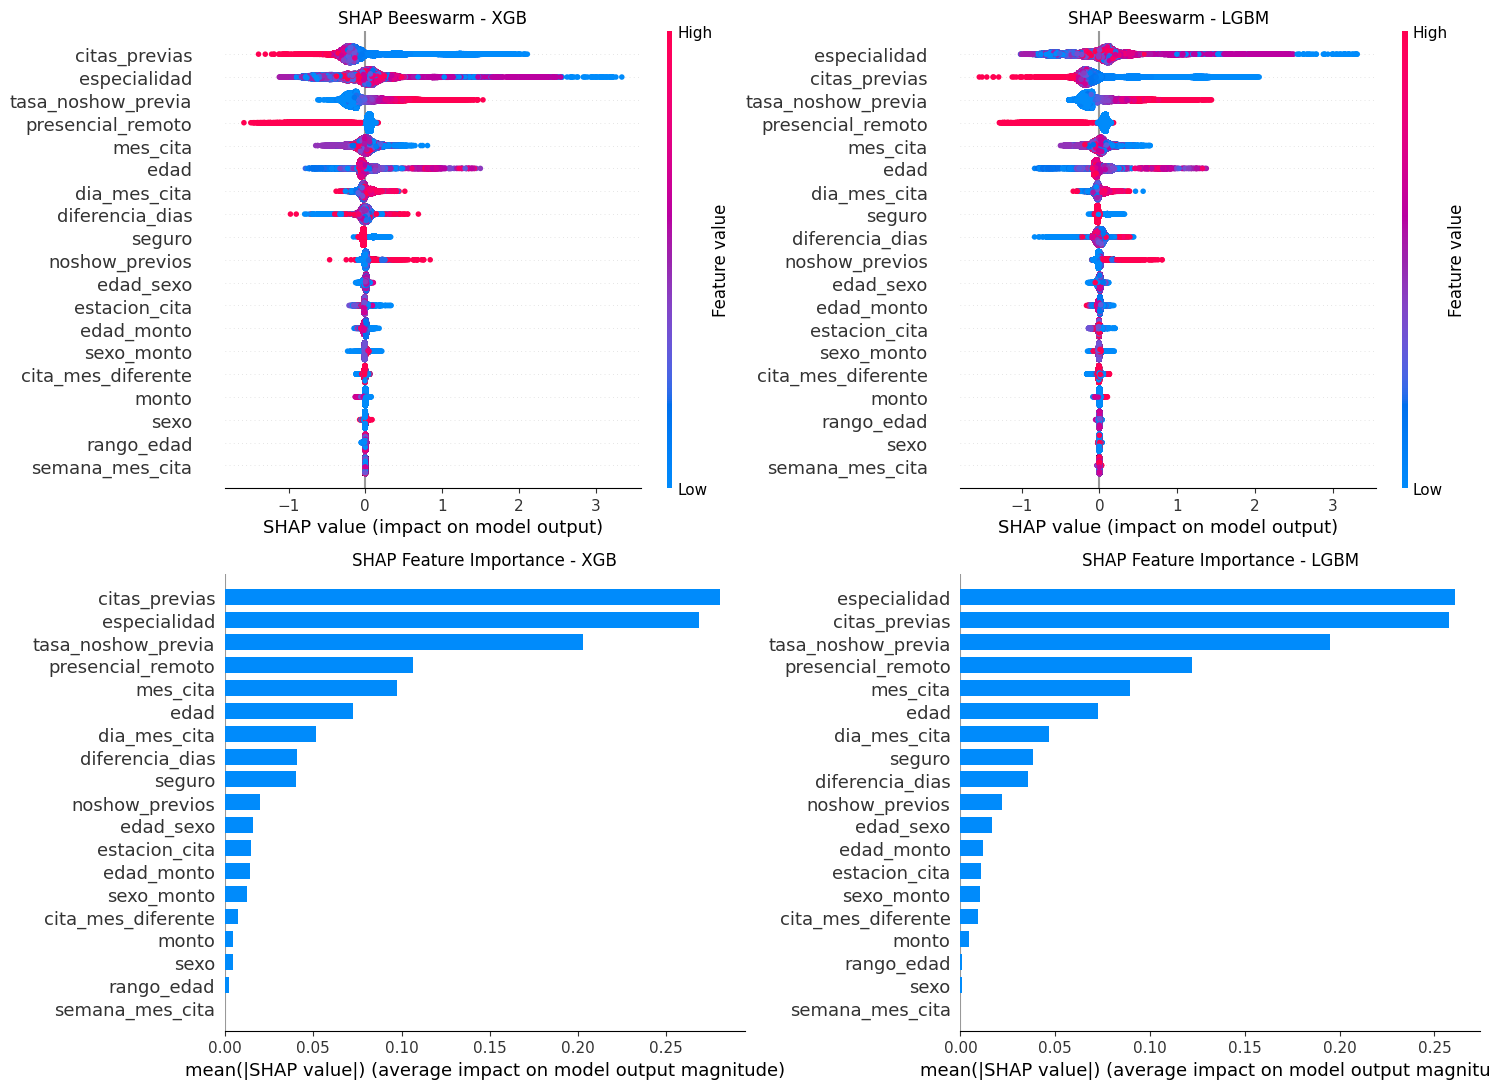

In [ ]:
target_col = 'atendido'
drop_cols = ['id', 'dia_solicitacita', 'dia_cita', target_col]
feature_cols = [c for c in data1.columns if c not in drop_cols]

X = data1[feature_cols].copy()
y = data1[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['category']).columns.tolist()

standard = StandardScaler()
X_train[num_cols] = standard.fit_transform(X_train[num_cols])
X_test[num_cols] = standard.transform(X_test[num_cols])

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

X_train = pd.concat([X_train[num_cols], X_train[cat_cols]], axis=1)
X_test = pd.concat([X_test[num_cols], X_test[cat_cols]], axis=1)

feature_names = X_train.columns.tolist()

# ── Ajuste por desbalance de clases ──────────────────────────────────────────
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"Clase 0: {n_neg:,} | Clase 1: {n_pos:,} | scale_pos_weight: {scale_pos_weight:.3f}")

# ── XGBoost nativo ───────────────────────────────────────────────────────────
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
dtest = xgb.DMatrix(X_test, feature_names=feature_names)

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.9,
    'seed': 42,
    'scale_pos_weight': scale_pos_weight,
}
xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=300)

# ── LightGBM nativo ──────────────────────────────────────────────────────────
lgb_train = lgb.Dataset(X_train, label=y_train, feature_name=feature_names, free_raw_data=False)

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.9,
    'verbose': -1,
    'seed': 42,
    'scale_pos_weight': scale_pos_weight,
}
lgb_model = lgb.train(lgb_params, lgb_train, num_boost_round=300)

# ── SHAP values ──────────────────────────────────────────────────────────────
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

explainer_lgb = shap.TreeExplainer(lgb_model)
shap_values_lgb = explainer_lgb.shap_values(X_test)

shap_values = {'XGB': shap_values_xgb, 'LGBM': shap_values_lgb}

# ── Visualización en grilla 2x2 ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
plot_titles = {'beeswarm': 'SHAP Beeswarm', 'bar': 'SHAP Feature Importance'}

for col_idx, (model_name, shap_vals) in enumerate(shap_values.items()):
    for row_idx, plot_type in enumerate(['beeswarm', 'bar']):
        plt.sca(axes[row_idx, col_idx])
        shap.summary_plot(
            shap_vals, X_test, feature_names=feature_names,
            plot_type=plot_type if plot_type == 'bar' else None,
            show=False, plot_size=None
        )
        axes[row_idx, col_idx].set_title(f'{plot_titles[plot_type]} - {model_name}')

plt.tight_layout()
plt.show()

In [11]:
#3.4. ReSeleccionar las variables (según importancia SHAP)
selected_cols = [
    'especialidad', 'citas_previas', 'mes_cita', 'presencial_remoto',
    'edad', 'dia_mes_cita', 'tasa_noshow_previa', 'seguro',
    'diferencia_dias', 'noshow_previos', 'atendido'
]
data1 = data1[selected_cols].copy()
#data1.info()

In [12]:
X = data1.drop('atendido', axis=1)
y = data1['atendido']
print(f"Variables predictoras (X):{X.shape} / Variable objetivo (y): {y.shape}")

Variables predictoras (X):(412579, 10) / Variable objetivo (y): (412579,)


In [13]:
# Gauardar como csv
X.to_csv('/content/prediccion-atenciones-medicas-salud/data/factures.csv', index=False, sep=';')
y.to_csv('/content/prediccion-atenciones-medicas-salud/data/target.csv', index=False, sep=';')
